---
# EM Algorithm for Remote Sensing: Spatial-Spectral GMM Clustering
---

---

# Introduction <a name="1"></a>

---

Proyek **OpenEarthMap Land Cover Clustering** adalah sebuah tugas *unsupervised semantic segmentation* yang bertujuan untuk mengelompokkan karakteristik tutupan lahan secara otomatis pada citra satelit resolusi tinggi. Menggunakan dataset **OpenEarthMap (OpenEarthMap_wo_xBD)**, sistem ini mengimplementasikan algoritme **Expectation-Maximization (EM)** melalui arsitektur **Gaussian Mixture Model (GMM)** sebagai mesin pengklusteran statistik utama.

Performa model dievaluasi secara ketat berdasarkan kemampuannya dalam mengenali batas-batas objek nyata menggunakan metrik **Mean Intersection over Union (mIoU)** dan **Overall Pixel Accuracy** yang diselaraskan secara otomatis menggunakan *Hungarian Algorithm*. Seluruh rancangan *pipeline* ini direkayasa secara efisien tanpa bergantung pada arsitektur *Deep Learning* berat, melainkan mengoptimalkan kombinasi fitur spektral RGB intrinsik, rekayasa indeks vegetasi `ExG` & `ExR`, serta koordinat spasial `(X, Y)` untuk menghasilkan segmentasi wilayah yang konvergen, solid, dan minim *noise*.

---
# Approach

Metodologi yang digunakan dalam proyek ini bertumpu pada pendekatan pengklusteran statistik berbasis model campuran (*statistical mixture modeling*) yang efisien secara komputasi. Menggantikan ketergantungan pada model *Deep Learning* yang intensif sumber daya, *pipeline* ini dirancang untuk memaksimalkan representasi fitur intrinsik piksel melalui rekayasa fitur multi-dimensi sebelum diesekusi oleh algoritme **Expectation-Maximization (EM)**.

*Pipeline* pemrosesan data, pelatihan, hingga evaluasi akhir disusun secara terstruktur sebagai berikut:

```text
OpenEarthMap Input Image (Batch, 3, 512, 512)
│
├── Feature Extraction & Engineering
│    ├── Color Channels (RGB Raw Features)
│    ├── Color Indices (Excess Green [ExG] & Excess Red [ExR])
│    └── Spatial Grid Awareness (Normalized X, Y Coordinates)
│
├── Reshaping & Normalization
│    └── flattening 3D Tensor ➔ 2D Matrix (N_pixels × 7 Features)
│    └── Robust Feature Scaling via StandardScaler
│
├── Core Optimization (EM Training)
│    │
│    ▼
│  Gaussian Mixture Model (GMM) Fitting (covariance_type='full')
│    ├── E-Step: Probabilistic Soft-Cluster Membership Allocation
│    └── M-Step: Iterative Parameter Update (Mean & Covariance Matrix)
│
└── Post-Processing & Metrics Alignment
     ├── Spatial Back-Mapping ➔ Target Dimensions (Batch, 512, 512)
     ├── Confidence Mapping (Extracting Max Posterior Probabilities)
     ├── Cluster Alignment to Ground Truth via Hungarian Algorithm
     └── Quantitative Validation (mIoU & Pixel Accuracy Matrix Assessment)

---

# Initialization <a name="2"></a>

---

---
## Environment

In [1]:
import os, platform, sys
print('Python :', sys.version)
print('OS     :', platform.system(), platform.release())
print('CWD    :', os.getcwd())

Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
OS     : Linux 6.6.122+
CWD    : /kaggle/working


---
## Install 

In [2]:
!pip install -q --upgrade albumentations

import os
import sys
import cv2
import numpy as np
import torch
import scipy
import sklearn
import albumentations as A

print(f"Python Version      : {sys.version.split()[0]}")
print(f"PyTorch Version     : {torch.__version__}")
print(f"NumPy Version       : {np.__version__}")
print(f"OpenCV Version      : {cv2.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"SciPy Version       : {scipy.__version__}")
print(f"Albumentations Ver. : {A.__version__}")
print(f"CUDA Available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device Name     : {torch.cuda.get_device_name(0)}")

Python Version      : 3.12.12
PyTorch Version     : 2.10.0+cu128
NumPy Version       : 2.0.2
OpenCV Version      : 4.13.0
Scikit-Learn Version: 1.6.1
SciPy Version       : 1.16.3
Albumentations Ver. : 2.0.8
CUDA Available      : True
GPU Device Name     : Tesla T4


---
## Libraries & Patching

In [3]:
import os
import warnings
import logging

# Mencegah OpenCV membanjiri log dengan peringatan tingkat C++
os.environ['OPENCV_LOG_LEVEL'] = 'OFF'

# Membisukan peringatan spesifik dari wrapper libtiff python
logging.getLogger("libtiff").setLevel(logging.ERROR)

# Membisukan warning standard python (GMM convergence/deprecation warnings)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# =================================================================
# 2. CORE LIBRARIES IMPORT
# =================================================================
# Sistem & Utilitas
import time
import sys
from pathlib import Path

# Komputasi Numerik & Manipulasi Tensor
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Pemrosesan Citra & Augmentasi Spasial
import cv2
import albumentations as A
from albumentations.pytorch import transforms

# Algoritme Machine Learning & Optimasi Kombinatorik
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, jaccard_score, classification_report
from scipy.optimize import linear_sum_assignment

# Visualisasi Data & Peta Spasial
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# 3. VERIFIKASI AKHIR
# =================================================================
print(f"PyTorch CUDA Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU Mode'}")
print("Patching Driver TIFF: Aktif [Log Bersih]")
print("Status: Semua modul berhasil dimuat dan siap dieksekusi!")

PyTorch CUDA Device: Tesla T4
Patching Driver TIFF: Aktif [Log Bersih]
Status: Semua modul berhasil dimuat dan siap dieksekusi!


---
## Settings

In [4]:
import random
import numpy as np
import torch
from pathlib import Path

# =================================================================
# 1. GLOBAL CONFIGURATION CLASS (CFG)
# =================================================================
class CFG:
    # Reproduksibilitas
    SEED = 42
    
    # Konfigurasi Dataset Spasial
    BASE_PATH = Path("/kaggle/input/datasets/dimaspashaakrilian/openearthmap/OpenEarthMap_wo_xBD")
    IMG_SIZE = 512
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    
    # Konfigurasi Inti Algoritme EM (GMM)
    N_CLASSES = 8
    COVARIANCE_TYPE = 'full'
    MAX_ITER = 100
    
    # Definisi Resmi Label Kelas OpenEarthMap (Urutan Standard)
    LABELS = [
        'Bareland', 
        'Grass', 
        'Pavement', 
        'Road', 
        'Tree', 
        'Water', 
        'Cropland', 
        'Building'
    ]

# =================================================================
# 2. SEED SYSTEM FOR REPRODUCIBILITY
# =================================================================
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Eksekusi penguncian seed
seed_everything(CFG.SEED)

# =================================================================
# 3. VERIFIKASI KONFIGURASI GLOBAL
# =================================================================
print(f"Deterministic Seed   : {CFG.SEED} [LOCKED]")
print(f"Target Image Size    : {CFG.IMG_SIZE}x{CFG.IMG_SIZE}")
print(f"Batch Size Specified : {CFG.BATCH_SIZE}")
print(f"EM GMM Target Classes: {CFG.N_CLASSES} Classes")
print(f"EM Covariance Type   : {CFG.COVARIANCE_TYPE}")
print(f"Dataset Target Path  : {CFG.BASE_PATH}")
print("Status: Parameter global terkunci secara aman!")

Deterministic Seed   : 42 [LOCKED]
Target Image Size    : 512x512
Batch Size Specified : 8
EM GMM Target Classes: 8 Classes
EM Covariance Type   : full
Dataset Target Path  : /kaggle/input/datasets/dimaspashaakrilian/openearthmap/OpenEarthMap_wo_xBD
Status: Parameter global terkunci secara aman!


---
# Data Acquisition
---

---
## Automated Path Mapping
Fungsi `get_paths` di bawah ini digunakan untuk membaca file teks pembagi data (`train.txt` / `val.txt`) dan secara otomatis mencocokkan nama file tersebut dengan lokasi absolut citra satelit beserta label pasangannya di dalam subfolder direktori Kaggle.

In [5]:
def get_paths(split_name):
    txt_file = CFG.BASE_PATH / f"{split_name}.txt"
    if not txt_file.exists():
        print(f"File {split_name}.txt tidak ditemukan di jalur: {txt_file}")
        return [], []

    with open(txt_file, 'r') as f:
        filenames = [line.strip().replace('.tif', '') for line in f.readlines()]
    
    img_paths, mask_paths = [], []
    
    # Mengindeks seluruh file gambar di subfolder secara rekursif
    all_tifs = list(CFG.BASE_PATH.glob("**/images/*.tif"))
    file_map = {f.stem: f.parent.parent for f in all_tifs}
    
    for name in filenames:
        pure_name = Path(name).stem
        if pure_name in file_map:
            city_dir = file_map[pure_name]
            img_paths.append(str(city_dir / "images" / f"{pure_name}.tif"))
            mask_paths.append(str(city_dir / "labels" / f"{pure_name}.tif"))
    
    return img_paths, mask_paths

---
## Custom Dataset Blueprint
Membuat *class* `OpenEarthMapDataset` yang mewarisi modul `torch.utils.data.Dataset`. Di dalam sel ini, gambar dibaca menggunakan OpenCV, dikonversi ke ruang warna RGB, dan dilakukan manipulasi pergeseran indeks matriks *mask* (dari skala 1-8 menjadi format 0-7) agar sesuai dengan standar komputasi indeks *array* Python.

In [6]:
class OpenEarthMapDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # Memuat citra resolusi tinggi (RGB)
        image = cv2.imread(self.img_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Memuat target mask (Ground Truth)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        # Konversi standardisasi indeks label 1-8 menjadi 0-7
        mask = mask.astype(np.int64) - 1
        mask[mask < 0] = 0 
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask

---
## Image Transformations & Normalization
Mengonfigurasi objek augmentasi spasial menggunakan `Albumentations`. Parameter resolusi gambar dikunci menggunakan nilai `CFG.IMG_SIZE` (512x512). Proses `A.Normalize` disetel dengan nilai rata-rata 0 dan standar deviasi 1 untuk mengonversi rentang intensitas warna piksel mentah (0-255) secara linear menjadi skala nilai kontinu 0 sampai 1 tanpa menggeser pusat variansnya.

In [7]:
train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1)), # Penskalaan linear ke rentang [0,1]
    transforms.ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=(0, 0, 0), std=(1, 1, 1)), # Penskalaan linear ke rentang [0,1]
    transforms.ToTensorV2()
])

---
## DataLoader Initialization & Verification
Langkah akhir dari pemuatan data: memanggil fungsi pemetaan file untuk subset data latihan (*training*) dan validasi, menginisialisasi objek `DataLoader` dengan multi-threading (`num_workers=2`), serta melakukan *sanity check* visual untuk memastikan tensor gambar dan peta label asli ter-load dengan sempurna ke memori runtime.

[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@40.605] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


Total Citra Training   : 2303
Total Citra Validasi   : 384
Dimensi Tensor Images  : torch.Size([8, 3, 512, 512])  # [Batch, Channels, H, W]
Dimensi Tensor Masks   : torch.Size([8, 512, 512])   # [Batch, H, W]


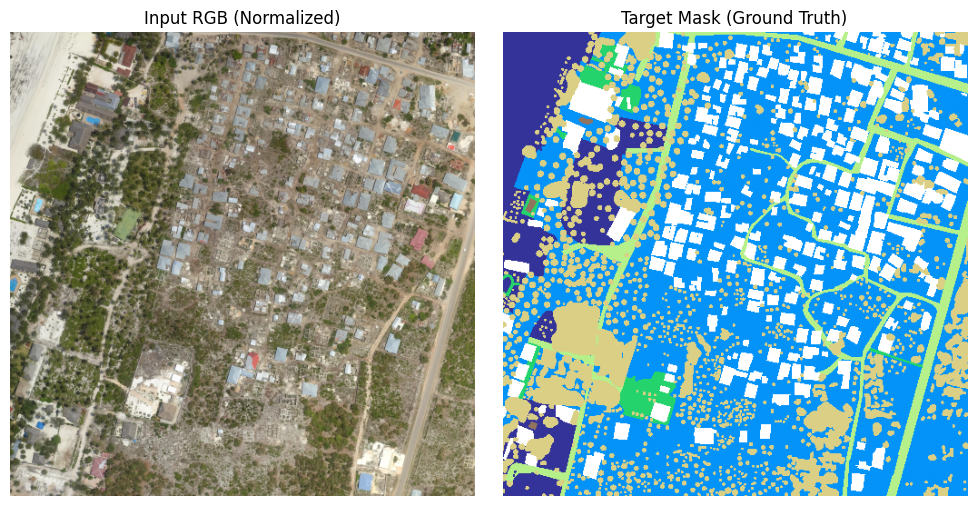

In [8]:
# Memetakan jalur file gambar dan mask
train_imgs, train_masks = get_paths("train")
val_imgs, val_masks = get_paths("val")

if len(train_imgs) > 0:
    # Inisialisasi Objek Dataset
    train_ds = OpenEarthMapDataset(train_imgs, train_masks, transform=train_transform)
    val_ds = OpenEarthMapDataset(val_imgs, val_masks, transform=val_transform)
    
    # Inisialisasi PyTorch DataLoader Terpusat via CFG
    train_loader = DataLoader(
        train_ds, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle=True, 
        num_workers=CFG.NUM_WORKERS
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=CFG.BATCH_SIZE, 
        shuffle=False, 
        num_workers=CFG.NUM_WORKERS
    )
    
    # Pengecekan Integritas Batch Pertama (Sanity Check)
    images, masks = next(iter(train_loader))
    print(f"Total Citra Training   : {len(train_imgs)}")
    print(f"Total Citra Validasi   : {len(val_imgs)}")
    print(f"Dimensi Tensor Images  : {images.shape}  # [Batch, Channels, H, W]")
    print(f"Dimensi Tensor Masks   : {masks.shape}   # [Batch, H, W]")
    
    # Visualisasi Sampel Data Lapangan
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(images[0].permute(1, 2, 0).numpy())
    plt.title("Input RGB (Normalized)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(masks[0].numpy(), cmap='terrain')
    plt.title("Target Mask (Ground Truth)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

---
# Preprocessing & Feature Engineering
---

---
## Feature Extraction Engine
Sel di bawah ini mendeklarasikan fungsi `extract_features`. Fungsi ini memproses tensor citra satu batch, mengekstrak fitur warna spektral asli, menghitung indeks warna klorofil/tanah, memetakan grid spasial dua dimensi, lalu menyatukannya ke dalam bentuk matriks fitur 2D siap pakai.

In [9]:
def extract_features(images):
    """
    Mengubah batch gambar menjadi matriks fitur 2D (Pixels, Features) yang terstandardisasi.
    Daftar Fitur Akhir: R, G, B, ExG (Excess Green), ExR (Excess Red), X, Y.
    """
    # 1. Konversi Tensor PyTorch ke Array NumPy Spasial
    # [Batch, Channels, Height, Width] -> [Batch, Height, Width, Channels]
    img_np = images.permute(0, 2, 3, 1).numpy()
    b, h, w, c = img_np.shape
    
    # Memisahkan matriks warna spektral RGB dasar
    R = img_np[:, :, :, 0]
    G = img_np[:, :, :, 1]
    B = img_np[:, :, :, 2]

    # 2. Perhitungan Indeks Spektral (Color Indices Formulation)
    # Excess Green (ExG): Mengisolasi pendaran spektral vegetasi hijau aktif
    exg = 2 * G - R - B
    
    # Excess Red (ExR): Mengisolasi reflektansi hangat material non-vegetasi/tanah
    exr = 1.4 * R - G

    # 3. Pembangunan Grid Koordinat Spasial Terbimbing
    # Membuat koordinat piksel linear yang dinormalisasi ke rentang [0, 1]
    x_coords, y_coords = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    x_coords = np.tile(x_coords, (b, 1, 1))
    y_coords = np.tile(y_coords, (b, 1, 1))

    # 4. Penggabungan Seluruh Fitur (Feature Stacking & Flattening)
    # Dimensi awal: (Batch, H, W, 7) -> Ditransformasikan ke Matriks 2D: (Total_Pixels, 7)
    features = np.stack([R, G, B, exg, exr, x_coords, y_coords], axis=-1)
    features_flattened = features.reshape(-1, 7)

    # 5. Penyelarasan Varians Menggunakan Standarisasi Z-Score
    # Mengamankan model dari bias akibat perbedaan skala unit pengukuran antar fitur
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_flattened)
    
    print(f"Total Piksel Terproses (Baris) : {features_scaled.shape[0]}")
    print(f"Total Dimensi Fitur (Kolom)    : {features_scaled.shape[1]}")
    print("Kombinasi Fitur                : [R, G, B, ExG, ExR, X, Y]")

    return features_scaled, (b, h, w)

---
## Pipeline Preprocessing Execution
Pada sel ini, kita mengambil satu batch sampel data tutupan lahan segar dari `train_loader`, kemudian mengeksekusi fungsi `extract_features` untuk memperoleh matriks `X_features` serta menyimpan dimensi asli spasialnya ke dalam variabel `spatial_dim`.

In [10]:
# Mengambil satu batch data sampel dari DataLoader latihan
images, masks = next(iter(train_loader))

# Mengeksekusi modul pipeline manipulasi dan ekstraksi fitur
X_features, spatial_dim = extract_features(images)

print(f"Metadata Dimensi Spasial Asli : {spatial_dim} # (Batch, Height, Width)")

[ WARN:0@42.937] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@42.937] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@42.937] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@42.937] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@42.941] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@42.941] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@42.941] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@42.941] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered


Total Piksel Terproses (Baris) : 2097152
Total Dimensi Fitur (Kolom)    : 7
Kombinasi Fitur                : [R, G, B, ExG, ExR, X, Y]
Metadata Dimensi Spasial Asli : (8, 512, 512) # (Batch, Height, Width)


---
# Reshaping Data
---

---
### Data Preparation Engine for EM
Sel di bawah ini mendefinisikan fungsi `prepare_for_em`. Fungsi ini memastikan dan memvalidasi kembali kecocokan dimensi data secara eksplisit serta mencetak laporan kesiapan data sebelum dialirkan ke dalam inti iterasi optimasi EM.

In [11]:
def prepare_for_em(features_scaled, spatial_dim):
    """
    Memvalidasi dan menyiapkan matriks fitur terstandardisasi agar siap 
    masuk ke dalam mesin optimasi algoritme EM (GMM).
    Input format: (Batch * Height * Width, N_Features)
    """
    b, h, w = spatial_dim
    
    # Memastikan data sudah berada pada representasi matriks 2D (N_Samples, N_Features)
    X_em = features_scaled
    
    print("Status Verifikasi       : Dimensi Matriks Valid")
    print(f"Total Sampel/Piksel (N) : {X_em.shape[0]:,}")
    print(f"Total Vektor Fitur (D)  : {X_em.shape[1]}")
    
    return X_em

---
## Execution and Dimensionality Check
Pada sel ini, fungsi penyiapan data dieksekusi menggunakan matriks fitur `X_features` dan informasi dimensi spasial asli `spatial_dim` yang telah diperoleh dari tahap sebelumnya. Hasil keluaran sel ini (`X_input_em`) akan menjadi input utama untuk fase pelatihan kluster GMM.

In [12]:
# Mengeksekusi penyiapan data akhir untuk input algoritme EM
X_input_em = prepare_for_em(X_features, spatial_dim)

print(f"Bentuk Matriks Akhir untuk EM : {X_input_em.shape} # (N_Samples, N_Features)")

Status Verifikasi       : Dimensi Matriks Valid
Total Sampel/Piksel (N) : 2,097,152
Total Vektor Fitur (D)  : 7
Bentuk Matriks Akhir untuk EM : (2097152, 7) # (N_Samples, N_Features)


---
# Algoritme EM (GMM)
---

---
## EM Training Engine Construction
Sel di bawah ini mendeklarasikan fungsi `train_em_gmm`. Fungsi ini membungkus instansiasi `GaussianMixture` menggunakan konfigurasi parameter dari objek global `CFG`. Selain menghasilkan label *hard clustering* (`predict`), fungsi ini juga mengekstrak matriks nilai probabilitas posterior kontinu (`predict_proba`) untuk kebutuhan analisis piksel campuran (*mixed-pixel analysis*).

In [13]:
def train_em_gmm(X_input, n_clusters=CFG.N_CLASSES):
    """
    Menjalankan arsitektur algoritme EM (GMM) secara iteratif 
    untuk pemetaan otomatis kluster tutupan lahan.
    """
    # 1. Inisialisasi Model Menggunakan Parameter Global CFG
    gmm = GaussianMixture(
        n_components=n_clusters, 
        covariance_type=CFG.COVARIANCE_TYPE, 
        max_iter=CFG.MAX_ITER, 
        random_state=CFG.SEED,
        verbose=1 # Mengaktifkan pelacakan konvergensi pada log output
    )

    print(f"Memulai iterasi EM untuk {n_clusters} kelas tutupan lahan...")
    start_time = time.time()

    # 2. Fit Model & Predict (Proses Inti E-Step dan M-Step)
    # labels: Hasil alokasi kluster kaku / Hard Clustering (0 sampai n_clusters-1)
    labels = gmm.fit_predict(X_input)
    
    # 3. Ekstraksi Probabilitas Matriks Posterior
    # probabilities: Hasil Soft Clustering untuk analisis ketidakpastian wilayah transisi
    probabilities = gmm.predict_proba(X_input)

    end_time = time.time()
    print("\n====== EM OPTIMIZATION REPORT ======")
    print(f"Durasi Komputasi EM  : {end_time - start_time:.2f} detik")
    print(f"Status Konvergen     : {gmm.converged_}")
    print(f"Total Iterasi Dicapai: {gmm.n_iter_}")
    print("------------------------------------")
    
    return labels, probabilities, gmm

---
## EM Optimization Model Execution
Pada sel ini, kita menjalankan proses pengklusteran berskala besar pada matriks data tabular `X_input_em`. Hasil keluaran dari sel ini berupa array label `labels`, matriks probabilitas keanggotaan `probs`, dan objek model `model_gmm` yang menyimpan seluruh bobot parameter statistik berkonvergen.

In [14]:
# Mengeksekusi pelatihan kluster berbasis algoritme EM
labels, probs, model_gmm = train_em_gmm(X_input_em, n_clusters=CFG.N_CLASSES)

print(f"Bentuk Array Labels  : {labels.shape} # (Total_Pixels,)")
print(f"Bentuk Matriks Probs : {probs.shape}  # (Total_Pixels, N_Classes)")

Memulai iterasi EM untuk 8 kelas tutupan lahan...
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.

====== EM OPTIMIZATION REPORT ======
Durasi Komputasi EM  : 144.71 detik
Status Konvergen     : True
Total Iterasi Dicapai: 32
------------------------------------
Bentuk Array Labels  : (2097152,) # (Total_Pixels,)
Bentuk Matriks Probs : (2097152, 8)  # (Total_Pixels, N_Classes)


---
# Post-Processing & Re-mapping
---

---
## Spatial Reconstruction Engine
Sel di bawah ini mendeklarasikan fungsi `post_process_results`. Fungsi ini memproses array hasil prediksi EM dan matriks probabilitas posterior untuk didefragmentasi kembali ke bentuk spasial dua dimensi per gambar dalam satu *batch*.

In [15]:
def post_process_results(labels, probs, spatial_dim):
    """
    Mentransformasikan kembali output linear GMM ke dalam ruang dimensi spasial asli
    serta mengekstrak peta keyakinan (Confidence Map).
    """
    b, h, w = spatial_dim
    n_clusters = probs.shape[1]

    # 1. Reshape Label Hasil Hard Clustering
    # Dari representasi data linear (B*H*W,) kembali ke bentuk spasial (B, H, W)
    labels_spatial = labels.reshape(b, h, w)
    
    # 2. Reshape Probabilitas Hasil Soft Clustering (Confidence Map Calculation)
    # Mengambil nilai probabilitas tertinggi per baris sebagai metrik keyakinan model
    conf_map = np.max(probs, axis=1).reshape(b, h, w)
    
    # 3. Penyusunan Probability Maps Kompleks untuk Tiap Kelas
    # Dimensi akhir: (Batch, Height, Width, N_Clusters)
    probs_spatial = probs.reshape(b, h, w, n_clusters)
    
    return labels_spatial, conf_map, probs_spatial

---
## Reconstruction Execution
Pada sel ini, kita mengeksekusi fungsi `post_process_results` menggunakan variabel array `labels` dan `probs` yang telah matang dari perhitungan iterasi EM sebelumnya.

In [16]:
# Mengeksekusi rekonstruksi dimensi spasial peta tutupan lahan
labels_map, confidence, all_probs = post_process_results(labels, probs, spatial_dim)

print(f"Bentuk Spasial Peta Klasifikasi : {labels_map.shape} # (Batch, H, W)")
print(f"Bentuk Spasial Peta Keyakinan   : {confidence.shape} # (Batch, H, W)")

Bentuk Spasial Peta Klasifikasi : (8, 512, 512) # (Batch, H, W)
Bentuk Spasial Peta Keyakinan   : (8, 512, 512) # (Batch, H, W)


---
## Multi-Plot Visualization Dashboard Construction
Sel di bawah ini mendefinisikan fungsi `plot_final_comparison`. Fungsi ini merangkul modul `matplotlib` untuk membangun dasbor visualisasi empat panel, yang menampilkan perbandingan antara Citra RGB Asli, *Ground Truth* (Label Manual), Hasil Kluster EM Mentah, dan Peta Ketidakpastian/Keyakinan Statistik (*Confidence Score*).

In [17]:
def plot_final_comparison(images, masks, labels_map, confidence, batch_idx=0):
    """
    Membangun dasbor visualisasi komparatif multi-panel untuk analisis spasial 
    hasil klasifikasi algoritme EM.
    """
    plt.figure(figsize=(20, 5))
    
    # 1. Visualisasi Citra Satelit Original RGB (Denormalisasi Spasial)
    # Mengembalikan susunan channel tensor PyTorch ke format NumPy: [C, H, W] -> [H, W, C]
    img_show = images[batch_idx].permute(1, 2, 0).numpy()
    img_show = (img_show * 1.0).clip(0, 1) # Menjaga rentang nilai piksel berada pada skala 0-1
    
    plt.subplot(1, 4, 1)
    plt.imshow(img_show)
    plt.title("Original RGB")
    plt.axis('off')

    # 2. Visualisasi Mask Target Asli (Ground Truth)
    plt.subplot(1, 4, 2)
    plt.imshow(masks[batch_idx], cmap='terrain')
    plt.title("Ground Truth (Manual)")
    plt.axis('off')

    # 3. Visualisasi Hasil Kluster Unsupervised EM (GMM Result)
    # Menggunakan colormap 'tab10' karena urutan pengelompokan nomor kluster masih acak
    plt.subplot(1, 4, 3)
    plt.imshow(labels_map[batch_idx], cmap='tab10')
    plt.title("EM (GMM) Result")
    plt.axis('off')

    # 4. Visualisasi Peta Tingkat Keyakinan EM (Confidence Map)
    # Colormap 'magma' digunakan untuk mempertegas area transisi (semakin terang = semakin yakin)
    plt.subplot(1, 4, 4)
    plt.imshow(confidence[batch_idx], cmap='magma')
    plt.title("EM Confidence Score")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

---
## Visualization Dashboard Render
Langkah akhir dari bab ini adalah mengeksekusi fungsi dasbor `plot_final_comparison` untuk merender sampel indeks ke-0 dari *batch* data saat ini. Hasil visual ini membantu kita mendeteksi secara kualitatif performa awal EM dalam mengidentifikasi pola geografis tutupan lahan.

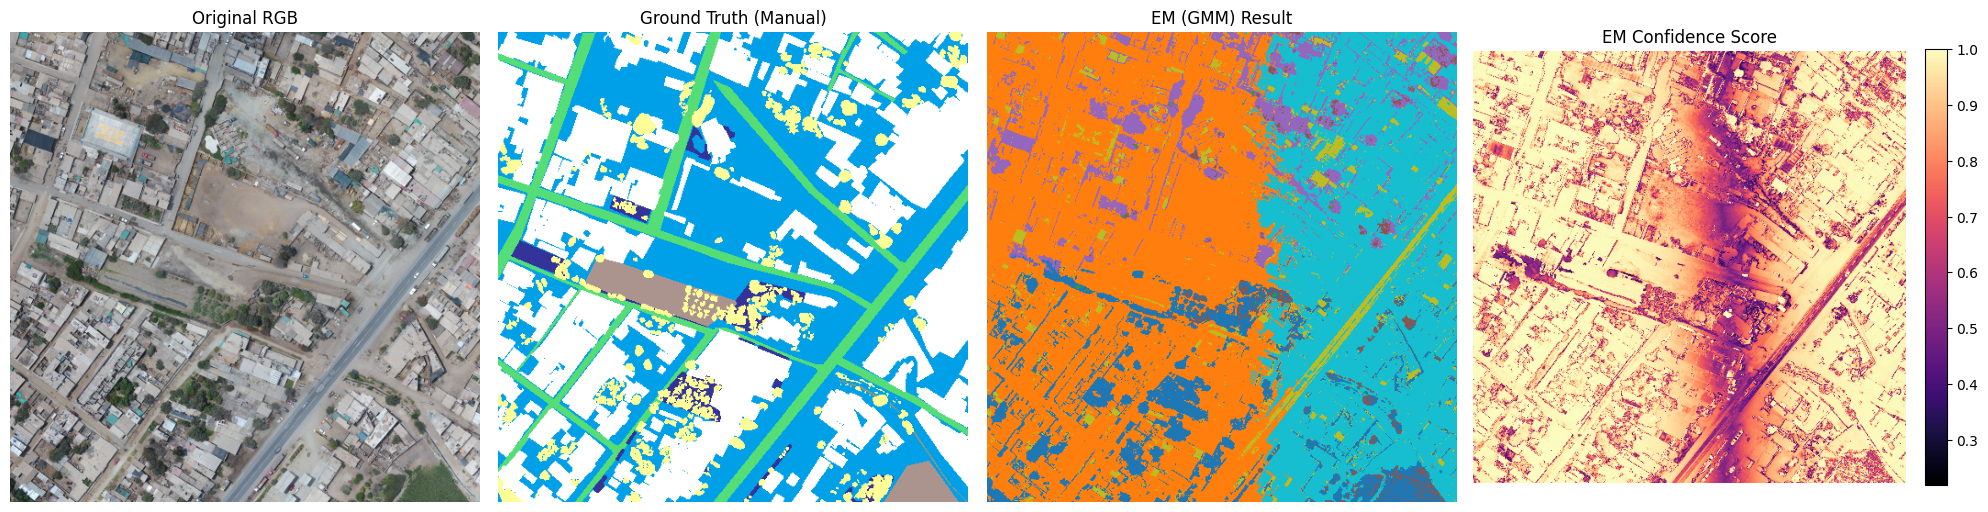

In [18]:
# Memanggil fungsi untuk menampilkan grafik dasbor perbandingan hasil kluster
plot_final_comparison(images, masks, labels_map, confidence, batch_idx=0)

---
# Model Evaluation & Quantitative Analysis
---

---
## Evaluation and Label Alignment Engine
Sel di bawah ini mendeklarasikan fungsi `evaluate_em_performance`. Fungsi ini meratakan (*flatten*) tensor spasial, menghitung matriks kontingensi (*confusion matrix*), menyelesaikan masalah penugasan label menggunakan *Hungarian Algorithm*, serta mengalkulasi skor mIoU per kelas tutupan lahan OpenEarthMap.

In [19]:
def evaluate_em_performance(gt_masks, pred_labels, n_clusters=CFG.N_CLASSES):
    """
    Menyelaraskan indeks kluster unsupervised EM dengan label Ground Truth 
    menggunakan Hungarian Algorithm, kemudian menghitung metrik akurasi spasial (mIoU).
    """
    # 1. Meratakan representasi spasial data untuk komputasi matriks statistika
    gt_flatten = gt_masks.flatten()
    pred_flatten = pred_labels.flatten()
    
    # 2. Menghitung Confusion Matrix awal sebagai dasar Cost Matrix
    cm = confusion_matrix(gt_flatten, pred_flatten, labels=range(n_clusters))
    
    # 3. Hungarian Combinatorial Optimization (Maximize Diagonal Agreement)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    # 4. Mentransformasikan label EM ke skema koordinat warna Ground Truth
    aligned_preds_flatten = np.array([mapping[l] for l in pred_flatten])
    aligned_preds = aligned_preds_flatten.reshape(pred_labels.shape)
    
    # 5. Perhitungan Metrik Akurasi Geospasial Standar
    # Menghitung Jaccard Score / IoU untuk masing-masing dari 8 kelas tutupan lahan
    iou_per_class = jaccard_score(gt_flatten, aligned_preds_flatten, average=None, labels=range(n_clusters))
    miou = np.mean(iou_per_class)
    
    # Menghitung nilai Pixel Accuracy keseluruhan
    accuracy = np.mean(gt_flatten == aligned_preds_flatten)
    
    # 6. Pencetakan Laporan Performa Kuantitatif
    print("===== HASIL EVALUASI ALGORITME EM =====")
    print(f"Overall Pixel Accuracy : {accuracy:.4f}")
    print(f"Mean IoU (mIoU)        : {miou:.4f}")
    print(f"Model Converged        : {model_gmm.converged_}")
    print(f"BIC Score              : {model_gmm.bic(X_input_em):.2f}")
    print("-" * 39)
    
    # Menampilkan detail performa IoU per objek tutupan lahan
    for i, score in enumerate(iou_per_class):
        label_name = CFG.LABELS[i] if i < len(CFG.LABELS) else f"Class {i}"
        print(f"{label_name:15} | IoU: {score:.4f}")
        
    return aligned_preds, cm, mapping

---
## Quantitative Metric Alignment Execution
Pada sel ini, kita mengeksekusi fungsi `evaluate_em_performance` menggunakan target *mask* asli dari data loader latihan (`masks.numpy()`) dan peta kluster rekahan spasial dari EM (`labels_map`). Hasil cetakan akan memperlihatkan skor akurasi deteksi per kelas objek secara transparan.

In [20]:
# Menjalankan mesin evaluasi dan menyelaraskan penomoran kluster otomatis
aligned_labels, conf_matrix, final_mapping = evaluate_em_performance(
    masks.numpy(), 
    labels_map, 
    n_clusters=CFG.N_CLASSES
)

===== HASIL EVALUASI ALGORITME EM =====
Overall Pixel Accuracy : 0.3372
Mean IoU (mIoU)        : 0.1880
Model Converged        : True
BIC Score              : -26225129.76
---------------------------------------
Bareland        | IoU: 0.0000
Grass           | IoU: 0.1269
Pavement        | IoU: 0.1409
Road            | IoU: 0.0225
Tree            | IoU: 0.2436
Water           | IoU: 0.2710
Cropland        | IoU: 0.4992
Building        | IoU: 0.2002


---
## Final Validation Dashboard (Confusion Matrix & Spatial Layout Comparison)
Langkah penutup dari proyek ini adalah melakukan visualisasi akhir. Sel di bawah ini merender matriks kebingungan (*Confusion Matrix*) untuk mengidentifikasi kelas objek apa saja yang sering membingungkan model EM (misal: kesalahan pemisahan antara `Road` dan `Pavement`). Dasbor ini juga menampilkan visualisasi spasial berdampingan antara *Ground Truth Mask* asli dan *EM Aligned Prediction Map* untuk pengecekan validitas peta secara kartografis.

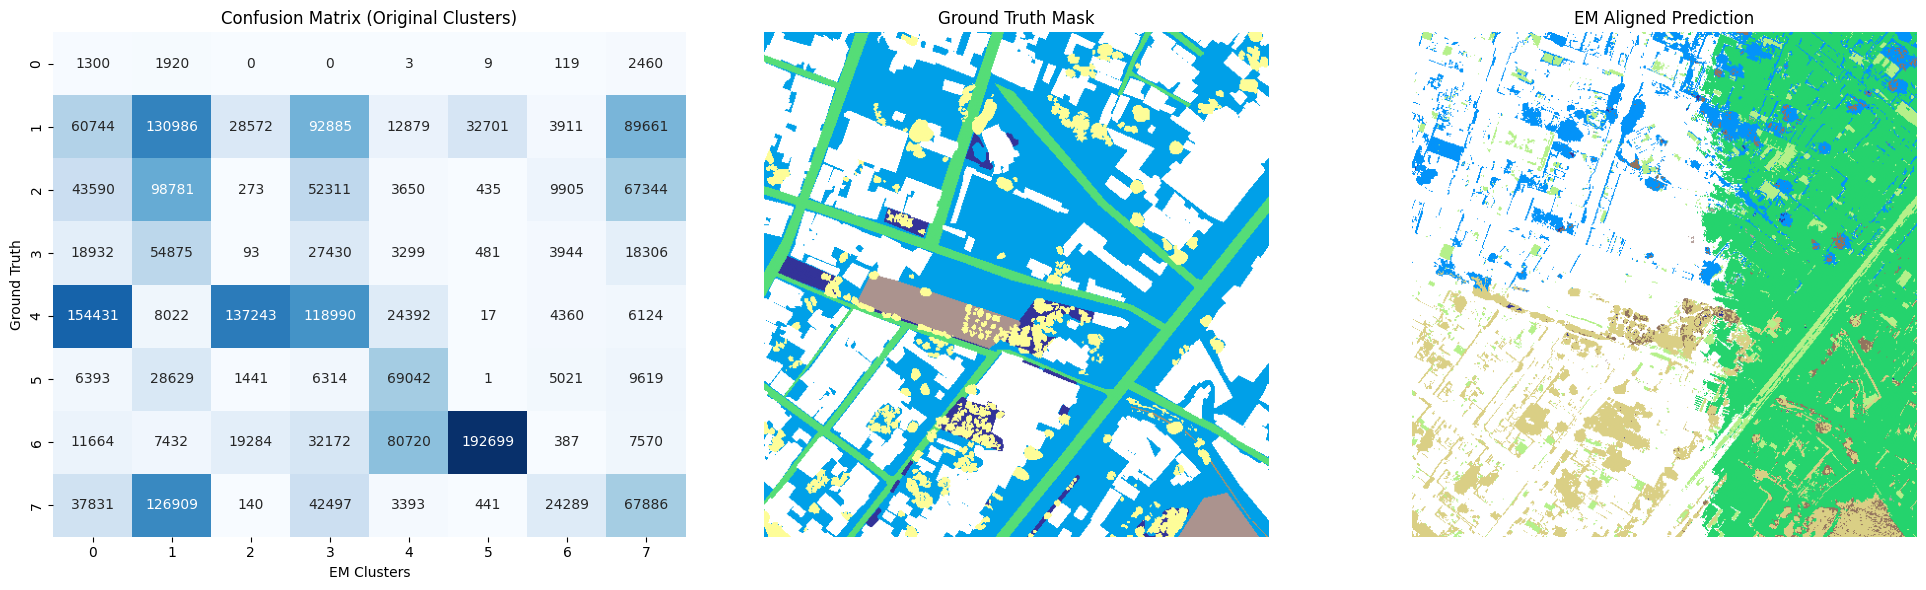

In [21]:
# Mengonfigurasi kanvas dasbor visualisasi akhir tiga panel
plt.figure(figsize=(20, 6))

# Panel 1: Representasi Matriks Kontingensi Kluster Asli vs Ground Truth
plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Original Clusters)")
plt.xlabel("EM Clusters")
plt.ylabel("Ground Truth")

# Panel 2: Peta Lokasi Riil Sampel (Ground Truth Mask)
plt.subplot(1, 3, 2)
plt.imshow(masks[0].numpy(), cmap='terrain')
plt.title("Ground Truth Mask")
plt.axis('off')

# Panel 3: Peta Hasil Rekonstruksi Kluster EM yang Sudah Diselaraskan Warnanya
plt.subplot(1, 3, 3)
plt.imshow(aligned_labels[0], cmap='terrain') # Mengunci skema colormap yang sama dengan GT
plt.title("EM Aligned Prediction")
plt.axis('off')

plt.tight_layout()
plt.show()